# DAta from https://github.com/INRB-UMIE/BDBV2026-Data/blob/main/data/insp_sitrep/processed/insp_sitrep__national_suspected_cases_under_investigation__daily.csv

In [ ]:
import pandas as pd
raw_url_confirmed_cases = "https://raw.githubusercontent.com/INRB-UMIE/BDBV2026-Data/refs/heads/main/data/insp_sitrep/processed/insp_sitrep__national_cumulative_confirmed_cases__daily.csv"
raw_url_confirmed_deaths = "https://raw.githubusercontent.com/INRB-UMIE/BDBV2026-Data/refs/heads/main/data/insp_sitrep/processed/insp_sitrep__national_cumulative_confirmed_deaths__daily.csv"
confirmed_cases=pd.read_csv(raw_url_confirmed_cases)
confirmed_deaths=pd.read_csv(raw_url_confirmed_deaths)
confirmed_cases.drop(columns='nom',inplace=True)
confirmed_deaths.drop(columns='nom',inplace=True)
confirmed_cases.rename(columns={'date':'Date','national_cumulative_confirmed_cases':'Confirmed_cases'},inplace=True)
confirmed_deaths.rename(columns={'date':'Date','national_cumulative_confirmed_deaths':'Confirmed_deaths'},inplace=True)
confirmed_cases['new_confirmed_cases'] = confirmed_cases['Confirmed_cases'].diff().fillna(confirmed_cases['Confirmed_cases']).clip(lower=0).astype(int)
confirmed_deaths['new_confirmed_deaths'] = confirmed_deaths['Confirmed_deaths'].diff().fillna(confirmed_deaths['Confirmed_deaths']).clip(lower=0).astype(int)

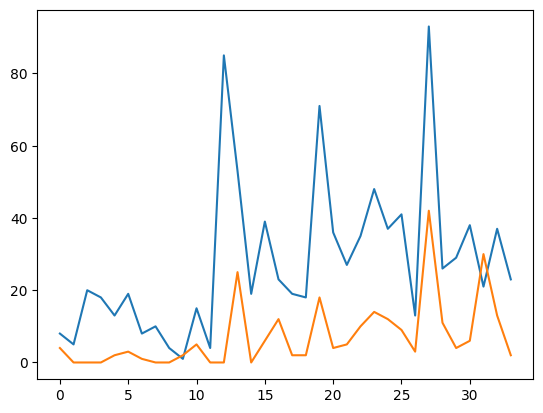

In [ ]:
import matplotlib.pyplot as plt
plt.plot(confirmed_cases['new_confirmed_cases'], label=f'new confirmed cases')
plt.plot(confirmed_deaths['new_confirmed_deaths'], label=f'new confirmed deaths')

In [ ]:
confirmed_cases['smoothed_confirmed_cases'] = confirmed_cases['new_confirmed_cases'].rolling(
    window=7,
    center=True,
    min_periods=1
).mean()
confirmed_deaths['smoothed_confirmed_deaths'] = confirmed_deaths['new_confirmed_deaths'].rolling(
    window=7,
    center=True,
    min_periods=1
).mean()

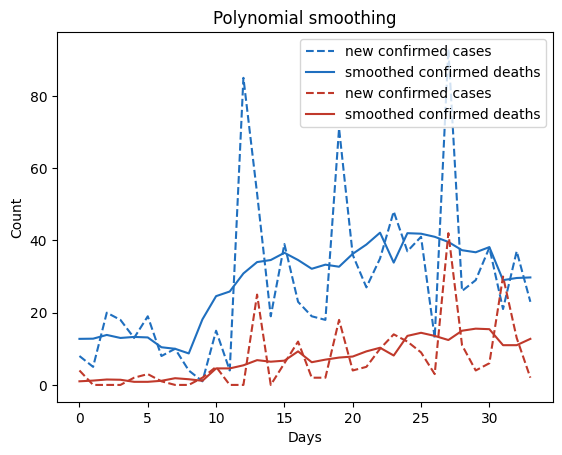

In [ ]:
BLUE  = '#1F6FBF'
RED   = '#C0392B'
plt.plot(confirmed_cases['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')
plt.plot(confirmed_cases['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')
plt.plot(confirmed_deaths['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')
plt.plot(confirmed_deaths['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')
plt.title('Polynomial smoothing')
plt.xlabel('Days')
plt.ylabel('Count')

plt.legend()

In [ ]:
df=confirmed_cases.copy()
df['smoothed_confirmed_deaths']=confirmed_deaths['smoothed_confirmed_deaths']
df.to_csv('/home/moez/Desktop/data_thiery/data ebola/insp_smoothed_incidence.csv')

## Multipatches data

In [49]:
import pandas as pd
cumulative_cases= pd.read_csv('https://raw.githubusercontent.com/INRB-UMIE/BDBV2026-Data/refs/heads/main/data/insp_sitrep/processed/insp_sitrep__cumulative_confirmed_cases__daily.csv')
cumulative_deaths= pd.read_csv('https://raw.githubusercontent.com/INRB-UMIE/BDBV2026-Data/refs/heads/main/data/insp_sitrep/processed/insp_sitrep__cumulative_confirmed_deaths__daily.csv')

cumulative_cases.head()

,nom,date,cumulative_confirmed_cases
0,Mongbalu,2026-05-14,0
1,Mongbalu,2026-05-15,0
2,Rwampara,2026-05-15,13
3,Bunia,2026-05-15,0
4,Mongbalu,2026-05-18,1


In [50]:
# Dictionary mapping the typos to the official names found in the population dataset
correction_map = {
    'Nyankunde': 'Nyakunde',
    'Mongbwalu': 'Mongbalu',
    'Gety': 'Gethy'
}

# Apply the corrections to your main cases/deaths dataset
cumulative_cases['nom'] = cumulative_cases['nom'].replace(correction_map)
cumulative_deaths['nom'] = cumulative_deaths['nom'].replace(correction_map)


In [51]:
import pandas as pd
import numpy as np

# 1. Replace 'ND' string with 0
cumulative_cases['cumulative_confirmed_cases'] = cumulative_cases['cumulative_confirmed_cases'].replace('ND', 0)
cumulative_cases['cumulative_confirmed_cases'] = cumulative_cases['cumulative_confirmed_cases'].astype(str).str.rstrip('-')
cumulative_cases['cumulative_confirmed_cases'] = pd.to_numeric(cumulative_cases['cumulative_confirmed_cases'], errors='coerce').fillna(0)
# 2. Convert the column to numbers so you can do math on it
cumulative_cases['cumulative_confirmed_cases'] = pd.to_numeric(cumulative_cases['cumulative_confirmed_cases'])

# 2. Define your rolling window size (e.g., 7 days/weeks)
window_size = 7

cumulative_cases['incidence_cases'] = cumulative_cases.groupby('nom')['cumulative_confirmed_cases'].transform(
    lambda x: x.diff().fillna(x).clip(lower=0).astype(int)
)
# 3. Compute rolling mean using .transform() to conserve original order
cumulative_cases['smoothed_confirmed_cases'] = cumulative_cases.groupby('nom')['incidence_cases'].transform(
    lambda x: x.rolling(window=window_size, min_periods=1).mean()
)

cumulative_cases = cumulative_cases.dropna(subset=['nom'])
print(cumulative_cases)

              nom        date  cumulative_confirmed_cases  incidence_cases  \
0        Mongbalu  2026-05-14                           0              0.0   
1        Mongbalu  2026-05-15                           0              0.0   
2        Rwampara  2026-05-15                          13             13.0   
3           Bunia  2026-05-15                           0              0.0   
4        Mongbalu  2026-05-18                           1              1.0   
..            ...         ...                         ...              ...   
798      Masereka  2026-06-21                           1              0.0   
799        Vuhovi  2026-06-21                           1              0.0   
800      Mabalako  2026-06-21                           1              0.0   
801     Musienene  2026-06-21                           2              1.0   
802  Miti-Murhesa  2026-06-21                           3              0.0   

     smoothed_confirmed_cases  
0                    0.000000  

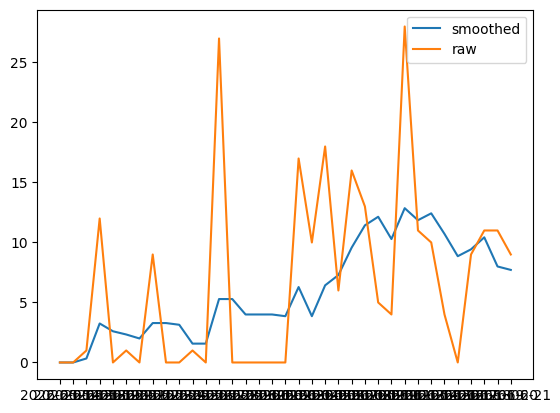

In [52]:
import matplotlib.pyplot as plt
plt.plot(cumulative_cases[cumulative_cases['nom'] == 'Mongbalu']['date'],cumulative_cases[cumulative_cases['nom'] == 'Mongbalu']['smoothed_confirmed_cases'],label='smoothed')
plt.plot(cumulative_cases[cumulative_cases['nom'] == 'Mongbalu']['date'],cumulative_cases[cumulative_cases['nom'] == 'Mongbalu']['incidence_cases'],label='raw')
plt.legend()

In [53]:
# 1. Replace 'ND' string with 0
cumulative_deaths['cumulative_confirmed_deaths'] = cumulative_deaths['cumulative_confirmed_deaths'].replace('ND', 0)
cumulative_deaths['cumulative_confirmed_deaths'] = cumulative_deaths['cumulative_confirmed_deaths'].astype(str).str.rstrip('-')
cumulative_deaths['cumulative_confirmed_deaths'] = pd.to_numeric(cumulative_deaths['cumulative_confirmed_deaths'], errors='coerce').fillna(0)
# 2. Convert the column to numbers so you can do math on it
cumulative_deaths['cumulative_confirmed_deaths'] = pd.to_numeric(cumulative_deaths['cumulative_confirmed_deaths'])

# 2. Define your rolling window size (e.g., 7 days/weeks)
window_size = 7

cumulative_deaths['incidence_deaths'] = cumulative_deaths.groupby('nom')['cumulative_confirmed_deaths'].transform(
    lambda x: x.diff().fillna(x).clip(lower=0).astype(int)
)
# 3. Compute rolling mean using .transform() to conserve original order
cumulative_deaths['smoothed_confirmed_deaths'] = cumulative_deaths.groupby('nom')['incidence_deaths'].transform(
    lambda x: x.rolling(window=window_size, min_periods=1).mean()
)

cumulative_deaths = cumulative_deaths.dropna(subset=['nom'])
print(cumulative_deaths)

              nom        date  cumulative_confirmed_deaths  incidence_deaths  \
0        Mongbalu  2026-05-14                          0.0               0.0   
1        Mongbalu  2026-05-15                          0.0               0.0   
2        Rwampara  2026-05-15                          0.0               0.0   
3           Bunia  2026-05-15                          0.0               0.0   
4        Mongbalu  2026-05-18                          0.0               0.0   
..            ...         ...                          ...               ...   
737      Masereka  2026-06-21                          0.0               0.0   
738        Vuhovi  2026-06-21                          1.0               0.0   
739      Mabalako  2026-06-21                          0.0               0.0   
740     Musienene  2026-06-21                          1.0               0.0   
741  Miti-Murhesa  2026-06-21                          1.0               0.0   

     smoothed_confirmed_deaths  
0     

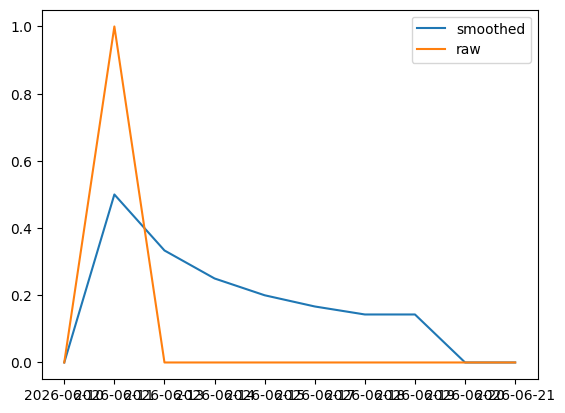

In [54]:
import matplotlib.pyplot as plt
plt.plot(cumulative_deaths[cumulative_deaths['nom'] == 'Masereka']['date'],cumulative_deaths[cumulative_deaths['nom'] == 'Masereka']['smoothed_confirmed_deaths'],label='smoothed')
plt.plot(cumulative_deaths[cumulative_deaths['nom'] == 'Masereka']['date'],cumulative_deaths[cumulative_deaths['nom'] == 'Masereka']['incidence_deaths'],label='raw')
plt.legend()

In [55]:

merged_df = pd.merge(
    cumulative_cases,
    cumulative_deaths[['date', 'nom', 'smoothed_confirmed_deaths']], 
    on=['date', 'nom'],
    how='left' 
)
merged_df

,nom,date,cumulative_confirmed_cases,incidence_cases,smoothed_confirmed_cases,smoothed_confirmed_deaths
0,Mongbalu,2026-05-14,0,0.0,0.000000,0.0
1,Mongbalu,2026-05-15,0,0.0,0.000000,0.0
2,Rwampara,2026-05-15,13,13.0,13.000000,0.0
3,Bunia,2026-05-15,0,0.0,0.000000,0.0
4,Mongbalu,2026-05-18,1,1.0,0.333333,0.0
...,...,...,...,...,...,...
780,Masereka,2026-06-21,1,0.0,0.000000,0.0
781,Vuhovi,2026-06-21,1,0.0,0.000000,0.0
782,Mabalako,2026-06-21,1,0.0,0.000000,0.0
783,Musienene,2026-06-21,2,1.0,0.333333,0.2


In [56]:
# Rename 'date' to 'Date'
merged_df = merged_df.rename(columns={'date': 'Date'})
# Pass the column names as a list inside the brackets
merged_df = merged_df[['Date', 'nom', 'smoothed_confirmed_cases', 'smoothed_confirmed_deaths']]
merged_df

,Date,nom,smoothed_confirmed_cases,smoothed_confirmed_deaths
0,2026-05-14,Mongbalu,0.000000,0.0
1,2026-05-15,Mongbalu,0.000000,0.0
2,2026-05-15,Rwampara,13.000000,0.0
3,2026-05-15,Bunia,0.000000,0.0
4,2026-05-18,Mongbalu,0.333333,0.0
...,...,...,...,...
780,2026-06-21,Masereka,0.000000,0.0
781,2026-06-21,Vuhovi,0.000000,0.0
782,2026-06-21,Mabalako,0.000000,0.0
783,2026-06-21,Musienene,0.333333,0.2


In [57]:
merged_df.to_csv('/home/moez/Desktop/data_thiery/data ebola/smoothed_incidence_multipatch.csv')